# Moosic — 02. Recursive Pipeline

Business-constrained clustering: split anything oversized, reassign to fix cross-branch drift, merge anything undersized. Starts fresh from the CSV — no dependency on `01_baseline_clustering.ipynb`.


## 1. Imports & Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from sklearn import set_config
import os

set_config(transform_output="pandas")
os.makedirs("../outputs", exist_ok=True)
RANDOM_STATE = 42

## 2. Load Data & Scale

In [13]:
df = pd.read_csv("../data/5000_songs.csv")
df.columns = df.columns.str.strip()

features = ['danceability', 'energy', 'acousticness', 'tempo', 'valence',
            'speechiness', 'instrumentalness']

scaler = MinMaxScaler().set_output(transform="pandas")
scaled_all = scaler.fit_transform(df[features])

print(f"Shape: {df.shape}")

Shape: (5235, 19)


## 3. Business Constraint: Target Playlist Size

In [14]:
TARGET_MIN, TARGET_MAX = 20, 60
MIN_SONGS_TO_SPLIT = 10
MAX_K_PER_SPLIT = 5

### 3a. Experiment — try a different target range here

Copy the values you want to test into a **new** cell below (don't overwrite Step 3 above) using distinct variable names, e.g. `TARGET_MIN_3A, TARGET_MAX_3A = 30, 40`, then re-run Steps 4-7 using those instead. Keeping Step 3's originals untouched means you can always get back to the main run.


## 4. Recursive Split

In [15]:
def recursive_split(indices, leaves):
    n = len(indices)
    subset_scaled = scaled_all.loc[indices]

    if n <= TARGET_MAX or n < MIN_SONGS_TO_SPLIT:
        leaves.append(indices)
        return

    k = min(MAX_K_PER_SPLIT, max(2, n // TARGET_MAX))
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(subset_scaled)

    for c in range(k):
        child_indices = [idx for idx, lab in zip(indices, labels) if lab == c]
        if child_indices:
            recursive_split(child_indices, leaves)

leaves = []
recursive_split(list(df.index), leaves)
print(f"Recursive split produced {len(leaves)} leaf clusters before reassignment.")

Recursive split produced 139 leaf clusters before reassignment.


## 5. Global Reassignment Pass

Fixes cross-branch drift: a song can end up in a branch just because it was the least-wrong option at that point in the tree, even if a different, already-finished branch is a better fit. This does a single flat nearest-centroid pass across **all** leaves together.


In [16]:
leaf_centroids = np.array([scaled_all.loc[leaf].mean(axis=0).values for leaf in leaves])

final_labels = pairwise_distances_argmin(scaled_all.values, leaf_centroids)
df['final_cluster'] = final_labels

reassigned = [df[df['final_cluster'] == c].index.tolist() for c in sorted(df['final_cluster'].unique())]
reassigned_centroids = np.array([scaled_all.loc[c].mean(axis=0).values for c in reassigned])

print(f"{len(reassigned)} clusters after reassignment.")

139 clusters after reassignment.


## 6. Merge Undersized Leaves

**History of bugs fixed here, kept as a record:**
1. Merging used to happen *before* reassignment, so reassignment silently undid it. Fixed by merging *after* reassignment, on the reassigned groups.
2. The merge target had no size cap, so one cluster could snowball past `TARGET_MAX`. Fixed by preferring targets that stay under the cap.
3. `pairwise_distances_argmin` was computed but never actually used — the "nearest" target was really just the first item in an unsorted list, causing one cluster to repeatedly "win" merges by list position (once ballooned to ~2200 songs). Fixed below by sorting real distances nearest-to-farthest.


In [17]:
def merge_undersized_leaves(leaves, leaf_centroids, min_size, max_size):
    leaves = [list(l) for l in leaves]
    leaf_centroids = leaf_centroids.copy()
    changed = True
    while changed:
        changed = False
        sizes = [len(l) for l in leaves]
        for i, size in enumerate(sizes):
            if size < min_size and len(leaves) > 1:
                candidates = [j for j in range(len(leaves)) if j != i]

                dists = np.linalg.norm(leaf_centroids[candidates] - leaf_centroids[i], axis=1)
                order = np.argsort(dists)
                sorted_candidates = [candidates[o] for o in order]

                nearest = next(
                    (j for j in sorted_candidates if len(leaves[j]) + size <= max_size),
                    sorted_candidates[0]
                )

                leaves[nearest].extend(leaves[i])
                del leaves[i]
                leaf_centroids = np.delete(leaf_centroids, i, axis=0)
                changed = True
                break
    return leaves, leaf_centroids

final_clusters, final_centroids = merge_undersized_leaves(reassigned, reassigned_centroids, TARGET_MIN, TARGET_MAX)

df['final_cluster'] = -1
for new_label, members in enumerate(final_clusters):
    df.loc[members, 'final_cluster'] = new_label

sizes = df['final_cluster'].value_counts().sort_index()
in_range = sizes[(sizes >= TARGET_MIN) & (sizes <= TARGET_MAX)]
print(f"{len(in_range)} / {len(sizes)} playlists within [{TARGET_MIN}, {TARGET_MAX}] ({100*len(in_range)/len(sizes):.0f}%)")

127 / 129 playlists within [20, 60] (98%)


## 7. Diagnostics: Size Histogram

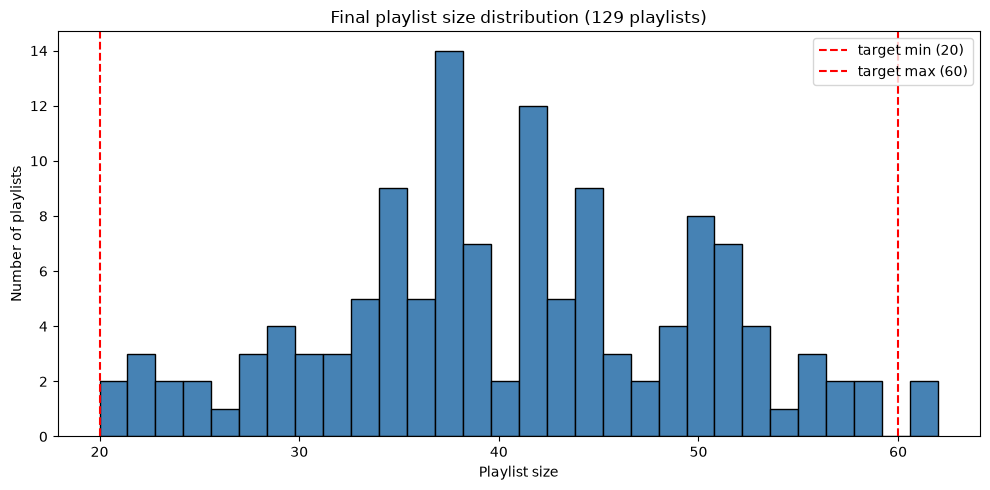

min=20, max=62, mean=40.6


In [18]:
plt.figure(figsize=(10, 5))
plt.hist(sizes, bins=30, color='steelblue', edgecolor='black')
plt.axvline(TARGET_MIN, color='red', linestyle='--', label=f'target min ({TARGET_MIN})')
plt.axvline(TARGET_MAX, color='red', linestyle='--', label=f'target max ({TARGET_MAX})')
plt.xlabel('Playlist size'); plt.ylabel('Number of playlists')
plt.title(f'Final playlist size distribution ({len(sizes)} playlists)')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/02_final_size_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"min={sizes.min()}, max={sizes.max()}, mean={sizes.mean():.1f}")

## 8. Save Outputs

In [19]:
df.to_csv("../outputs/songs_final_clusters.csv", index=False)
print("Saved to ../outputs/songs_final_clusters.csv")

Saved to ../outputs/songs_final_clusters.csv


## 9. Spot-Check Radar — a Small, Readable Sample

With ~100+ final clusters, a radar chart of *all* of them is unreadable (this is exactly what went wrong at k=125 a few sessions back). Instead, sample a handful and look at those — enough to sanity-check coherence without visual overload.


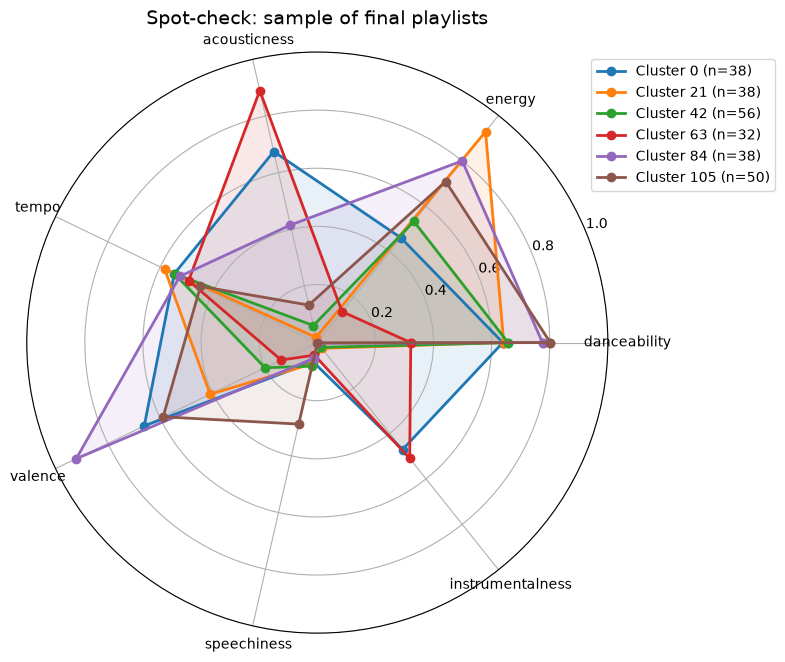

In [20]:
sample_ids = sorted(sizes.index)[::max(1, len(sizes) // 6)][:6]
sample_centroids = pd.DataFrame(
    {c: scaled_all.loc[df[df['final_cluster'] == c].index].mean() for c in sample_ids}
).T

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]
for c in sample_ids:
    values = sample_centroids.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {c} (n={sizes[c]})')
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_ylim(0, 1)
ax.set_title('Spot-check: sample of final playlists', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig("../outputs/02_spotcheck_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. t-SNE — Does It Actually Help Here?

Worth testing honestly rather than assuming either way — your teacher's caution that t-SNE "doesn't always have much use" lines up with what we found in practice a few sessions ago, and it's consistent with what the lesson material itself says: t-SNE is a visualisation aid, not a definitive evaluation method, and it becomes computationally heavier and visually noisier as the number of categories grows.

### 10a. The naive version (colored by all ~100+ final clusters)

This is deliberately the version that goes wrong, kept here as a documented example rather than skipped: `viridis` is a **continuous** colormap, built for numbers with a real order (like temperature). Cluster IDs have no such order, so nearby cluster numbers end up nearly the same color regardless of whether the clusters are actually similar. With this many categories, no color scheme would stay readable anyway — this cell demonstrates *why*, rather than just asserting it.


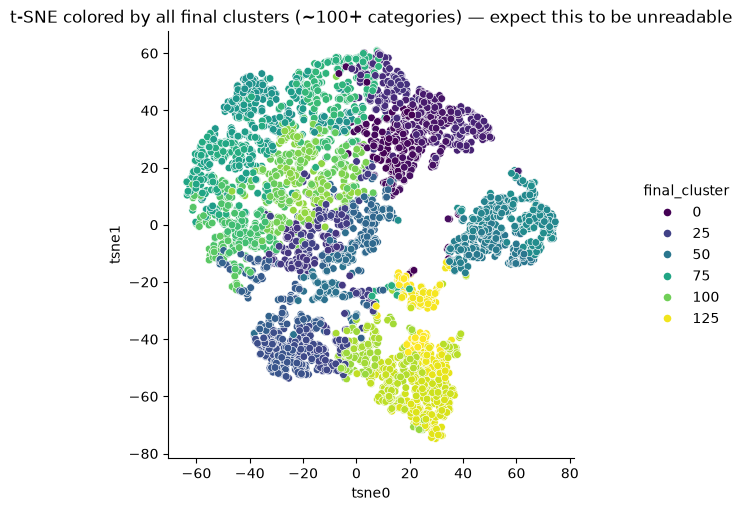

In [21]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
tsne_results = tsne.fit_transform(scaled_all)
tsne_results['final_cluster'] = df['final_cluster']

sns.relplot(
    data=tsne_results,
    x=tsne_results.columns[0], y=tsne_results.columns[1],
    hue='final_cluster', palette='viridis', s=30
).set(title="t-SNE colored by all final clusters (~100+ categories) — expect this to be unreadable")

### 10b. A version where t-SNE actually earns its place

Color by the broad, pre-split k=8 grouping instead — few enough categories for a qualitative palette to actually work, and closer to the scale t-SNE is genuinely good at (a handful of regions, not 100+ fine slices).


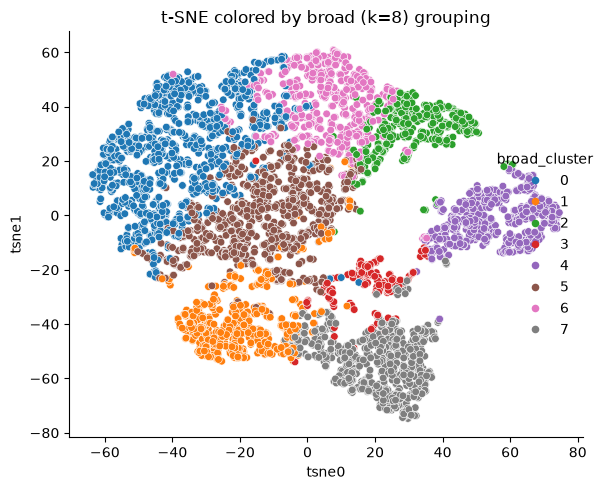

In [23]:
broad_kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
tsne_results['broad_cluster'] = broad_kmeans.fit_predict(scaled_all)

sns.relplot(
    data=tsne_results,
    x=tsne_results.columns[0], y=tsne_results.columns[1],
    hue='broad_cluster', palette='tab10', s=30
).set(title="t-SNE colored by broad (k=8) grouping")
plt.tight_layout()
plt.savefig("../outputs/02_kmeans_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

**Honest takeaway to write in the report either way:** compare 10a and 10b directly. If 10b still looks messy/overlapping even with only 8 readable colors, that's genuine evidence the underlying feature space doesn't separate cleanly — a real finding, not a plotting failure. If 10b looks reasonably distinct while 10a looked chaotic, that confirms the earlier diagnosis: the *tool* works fine, it was the *category count* that broke it, not t-SNE itself. Either result is worth stating plainly — this is exactly the kind of case where the honest answer is more useful than a confident one.


---
**Next notebook:** `03_cluster_deepdive.ipynb` — inspecting and re-splitting a specific oversized cluster.
